# VELOCE III: Reconstructing Radial Velocity Curves of Classical Cepheids

Giordano Viviani and Richard I. Anderson (2025)

email: giordano.viviani@proton.me

This notebook reproduce step-by-step the analysis conducted to create the framework published in *Viviani et Anderson 2025* (doi: 10.48550/arXiv.2511.10534)

In [1]:
%matplotlib inline

import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from astropy.io import votable
from matplotlib import rc
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# Import the veloce framework library
import velocefw as vf

rc("text", usetex=True)
rc("text.latex", preamble=r"\usepackage{amsmath}")
rc("font", family="serif")

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

# Okabe and Ito colorscheme
color_safe = {
    "black": "#000000",
    "light_green": "#009E73",
    "blue": "#0072B2",
    "light_blue": "#56B4E9",
    "yellow": "#F0E442",
    "orange": "#E69F00",
    "dark_orange": "#D55E00",
    "pink": "#CC79A7",
}

# Label and font sizes for plots
label_size = 11

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Prepare Data
### VELOCE DR1 data
Accessing the VELOCE DR1 (Anderson, Viviani et al, 2024) data.

The code makes use of the environment variable DATASETS, and it assumes the VELOCE DR1 fits files are in a sub-folder.
Please change the path to where you saved the VELOCE DR1 fits files. 

In [2]:
datasets_dir = Path(os.environ.get("DATASETS", "")).expanduser()
veloce_data_dir = datasets_dir / "veloce_dr1_zenodo"

Reading all the headers into a pandas.DataFrame

In [3]:
# Entries not needed for the analysis
entries_to_remove = ["SIMPLE", "BITPIX", "NAXIS", "EXTEND"]

header_list = []
for f in veloce_data_dir.iterdir():
    if f.suffix.lower() == ".fits":
        header = vf.get_header(f)
        for entry in entries_to_remove:
            header.pop(entry, None)
        header_list.append(header)

veloce_headers = pd.DataFrame(header_list).sort_values("NAME").reset_index(drop=True)

Selecting only Classical Cepheids that have been modeled using the available `BOOL_FIT_AVAILABLE` key.

In [4]:
veloce_headers = veloce_headers[veloce_headers["BOOL_FIT_AVAILABLE"]]
veloce_headers = veloce_headers.reset_index(drop=True)

#### Observations
Get the actual observations for all the targets with an available pulsation model.
We are interested into retrieving also the `MASK` column. The boolean column informs us if the datapoint was used to determine the pulsational model in VELOCE-I.

In [5]:
read_columns = ["BJD", "RV", "RV_ERR", "MASK"]
veloce_data = pd.DataFrame()
for name in veloce_headers["NAME"]:
    file = veloce_data_dir / f"{name.replace(' ', '_')}.fits"
    temp = vf.get_table(file, 1, columns=read_columns)
    temp["NAME"] = name
    veloce_data = pd.concat([veloce_data, temp], ignore_index=True)

#### Models
Here, we get the published coefficients for the fitted models.

We load the coefficients array from VELOCE's fits files and then slice it into its components:
- `VGAMMA`: constant value added to the model
- `FS_COEFFS`: Fourier series coefficients
- `POLY_COEFFS`: possible polynomial coefficients used in the fit. None if no polynomial was used

In [6]:
read_columns = ["COEFF", "COEFF_ERR"]
veloce_fit = pd.DataFrame()
for _, header in veloce_headers.iterrows():
    name = header["NAME"]
    nharm = int(header["N_TERMS_FS"])
    # Slices for the coefficients in the order: constant, fs, poly
    constant_idx = 0
    fs_idx = slice(1, 2 * nharm + 1)
    poly_idx = slice(2 * nharm + 1, None)
    # Read the coefficients from the FITS file
    file = veloce_data_dir / f"{name.replace(' ', '_')}.fits"
    coeff_table = vf.get_table(file, 2, columns=read_columns)
    temp_coeff = coeff_table["COEFF"].to_numpy()
    temp_coeff_err = coeff_table["COEFF_ERR"].to_numpy()

    # Extract the coefficients for each component
    vgamma = temp_coeff[constant_idx]
    fs_coeffs = temp_coeff[fs_idx]
    poly_coeffs = temp_coeff[poly_idx] if header["BOOL_POLYNOMIAL"] else None

    vgamma_err = temp_coeff_err[constant_idx]
    fs_coeffs_err = temp_coeff_err[fs_idx]
    poly_coeffs_err = temp_coeff_err[poly_idx] if header["BOOL_POLYNOMIAL"] else None

    # Store the coefficients in a DataFrame
    temp = pd.DataFrame(
        {
            "NAME": name,
            "VGAMMA": [vgamma],
            "FS_COEFFS": [fs_coeffs],
            "POLY_COEFFS": [poly_coeffs],
            "VGAMMA_ERR": [vgamma_err],
            "FS_COEFFS_ERR": [fs_coeffs_err],
            "POLY_COEFFS_ERR": [poly_coeffs_err],
        },
    )
    veloce_fit = pd.concat([veloce_fit, temp], ignore_index=True)

### Gaia DR3 data 
We load the data in Gaia DR3's `vari_cepheids` table.
We are interested into retrieving the photometric epochs determined by Gaia to determine the phase differnce with VELOCE's determined epoch.

In particular, later in the analysis, we want to randomize the phase of our measurements to better simulate how the templates perform over sparse data collected without prior knowledge of the phase.

In [7]:
gaiadr3_data_dir = datasets_dir / "gaia_dr3"

votable_file_gaiadr3 = gaiadr3_data_dir / "VOTableFiles" / "gaiadr3.vari_cepheids.vot"
df_gaiadr3 = (
    votable.parse(votable_file_gaiadr3).get_first_table().to_table().to_pandas()
)

From the entire list we select only the targets within VELOCE (remember alf UMi is not present in Gaia DR3)

In [8]:
df_gaiadr3_selection = df_gaiadr3[
    df_gaiadr3["source_id"].isin(veloce_headers["GAIA_DR3_SOURCE_ID"].astype(int))
]
# Delete the original DataFrame to free up memory
del df_gaiadr3

Check which targets are missing and then calculate the difference in epoch and period between the photometric Gaia data and VELOCE

The difference in phase is measured at GAIA's epoch and is measured using VELOCE's ($\Delta\phi_V$) and Gaia's ($\Delta\phi_G$) period as follows:
- $\Delta\phi_V = \frac{E_G - E_V}{P_V}$
- $\Delta\phi_G = \frac{E_G - E_V}{P_G}$

In [9]:
epoch_offset_gaiadr3 = 2455197.5  # = J2010.0
epoch_offset_veloce = 2400000.0

gaia_veloce_delta_epoch_list = []
for _, header in veloce_headers.iterrows():
    source_id = int(header["GAIA_DR3_SOURCE_ID"])
    if source_id not in df_gaiadr3_selection["source_id"].to_numpy():
        msg = f"{header['NAME']} (id: {source_id}) is missing in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue

    # Gaia Data
    gaia_data = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == source_id]
    gaia_period = gaia_data["pf"].to_numpy()[0]
    gaia_period_err = gaia_data["pf_error"].to_numpy()[0]
    gaia_epoch_g = gaia_data["epoch_g"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_bp = gaia_data["epoch_bp"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_rp = gaia_data["epoch_rp"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_rv = gaia_data["epoch_rv"].to_numpy()[0] + epoch_offset_gaiadr3

    # VELOCE Data
    veloce_epoch = header["E"] + epoch_offset_veloce
    veloce_period = header["P"]
    veloce_period_err = header["P_ERR"]

    if np.isnan(gaia_epoch_g):
        msg = f"{header['NAME']} (id: {source_id}) has NaN epoch in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue

    if np.isnan(gaia_period):
        msg = f"{header['NAME']} (id: {source_id}) has NaN period in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue

    delta_phase_g_v = (gaia_epoch_g - veloce_epoch) / veloce_period % 1
    delta_phase_g_g = (gaia_epoch_g - veloce_epoch) / gaia_period % 1
    delta_phase_bp_v = (gaia_epoch_bp - veloce_epoch) / veloce_period % 1
    delta_phase_bp_g = (gaia_epoch_bp - veloce_epoch) / gaia_period % 1
    delta_phase_rp_v = (gaia_epoch_rp - veloce_epoch) / veloce_period % 1
    delta_phase_rp_g = (gaia_epoch_rp - veloce_epoch) / gaia_period % 1
    delta_phase_rv_v = (gaia_epoch_rv - veloce_epoch) / veloce_period % 1
    delta_phase_rv_g = (gaia_epoch_rv - veloce_epoch) / gaia_period % 1

    # Cycle separation and time drift calculations
    n_cycle_separation_g = np.abs(gaia_epoch_g - veloce_epoch) / veloce_period
    n_cycle_separation_bp = np.abs(gaia_epoch_bp - veloce_epoch) / veloce_period
    n_cycle_separation_rp = np.abs(gaia_epoch_rp - veloce_epoch) / veloce_period
    n_cycle_separation_rv = np.abs(gaia_epoch_rv - veloce_epoch) / veloce_period

    delta_period = gaia_period - veloce_period
    _term_error_prop = gaia_period_err**2 + veloce_period_err**2
    delta_time_drift_g = n_cycle_separation_g * delta_period
    delta_time_drift_g_err = np.sqrt(n_cycle_separation_g**2 * _term_error_prop)
    delta_time_drift_bp = n_cycle_separation_bp * delta_period
    delta_time_drift_bp_err = np.sqrt(n_cycle_separation_bp**2 * _term_error_prop)
    delta_time_drift_rp = n_cycle_separation_rp * delta_period
    delta_time_drift_rp_err = np.sqrt(n_cycle_separation_rp**2 * _term_error_prop)
    delta_time_drift_rv = n_cycle_separation_rv * delta_period
    delta_time_drift_rv_err = np.sqrt(n_cycle_separation_rv**2 * _term_error_prop)

    gaia_veloce_delta_epoch_list.append(
        {
            "NAME": header["NAME"],
            "P": veloce_period,
            "DELTA_PHASE_G_V": (delta_phase_g_v + 0.5) % 1 - 0.5,
            "DELTA_PHASE_G_G": (delta_phase_g_g + 0.5) % 1 - 0.5,
            "DELTA_PHASE_BP_V": (delta_phase_bp_v + 0.5) % 1 - 0.5,
            "DELTA_PHASE_BP_G": (delta_phase_bp_g + 0.5) % 1 - 0.5,
            "DELTA_PHASE_RP_V": (delta_phase_rp_v + 0.5) % 1 - 0.5,
            "DELTA_PHASE_RP_G": (delta_phase_rp_g + 0.5) % 1 - 0.5,
            "DELTA_PHASE_RV_V": (delta_phase_rv_v + 0.5) % 1 - 0.5,
            "DELTA_PHASE_RV_G": (delta_phase_rv_g + 0.5) % 1 - 0.5,
            "DELTA_PERIOD": delta_period,
            "N_CYCLES_SEPARATION_G": n_cycle_separation_g,
            "N_CYCLES_SEPARATION_BP": n_cycle_separation_bp,
            "N_CYCLES_SEPARATION_RP": n_cycle_separation_rp,
            "N_CYCLES_SEPARATION_RV": n_cycle_separation_rv,
            "DELTA_PHASE_DRIFT_G": delta_time_drift_g / veloce_period,
            "DELTA_PHASE_DRIFT_G_ERR": delta_time_drift_g_err / veloce_period,
            "DELTA_PHASE_DRIFT_BP": delta_time_drift_bp / veloce_period,
            "DELTA_PHASE_DRIFT_BP_ERR": delta_time_drift_bp_err / veloce_period,
            "DELTA_PHASE_DRIFT_RP": delta_time_drift_rp / veloce_period,
            "DELTA_PHASE_DRIFT_RP_ERR": delta_time_drift_rp_err / veloce_period,
            "DELTA_PHASE_DRIFT_RV": delta_time_drift_rv / veloce_period,
            "DELTA_PHASE_DRIFT_RV_ERR": delta_time_drift_rv_err / veloce_period,
        },
    )

gaia_veloce_delta = pd.DataFrame(gaia_veloce_delta_epoch_list)

AH Vel (id: 5519380081746387328) has NaN period in vari_cepheids.
ASAS J064540+0330.4 (id: 3127416965285738880) has NaN period in vari_cepheids.
ASAS J064553+1003.8 (id: 3350719221309022720) has NaN period in vari_cepheids.
ASAS J084951-4627.2 (id: 5329675052782690944) has NaN period in vari_cepheids.
ASAS J091606-5418.6 (id: 5310680130436798336) has NaN period in vari_cepheids.
ASAS J100814-5856.6 (id: 5258280842214814336) has NaN period in vari_cepheids.
ASAS J101016-5811.2 (id: 5258420858142702208) has NaN period in vari_cepheids.
ASAS J102558-5956.8 (id: 5255209665741407744) has NaN period in vari_cepheids.
ASAS J104300-6131.2 (id: 5254027106636092928) has NaN period in vari_cepheids.
ASAS J155847-5341.8 (id: 5980814424369504256) has NaN period in vari_cepheids.
ASAS J162811-5111.9 (id: 5934398717159140736) has NaN period in vari_cepheids.
ASAS J173848-3304.4 (id: 4054155699611497472) has NaN period in vari_cepheids.
ASAS J174108-2328.5 (id: 4116471792510901248) has NaN period in v

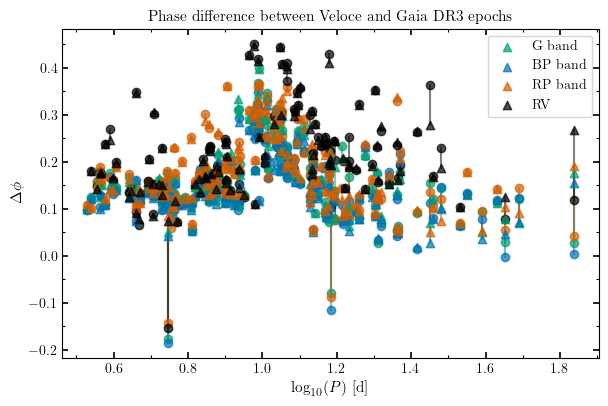

In [10]:
width = 3.46 * 2
height = width / 1.618
fig, axs = plt.subplots(figsize=(width, height))
x = np.log10(gaia_veloce_delta["P"])
y_v_names = [
    "DELTA_PHASE_G_V",
    "DELTA_PHASE_BP_V",
    "DELTA_PHASE_RP_V",
    "DELTA_PHASE_RV_V",
]
y_g_names = [
    "DELTA_PHASE_G_G",
    "DELTA_PHASE_BP_G",
    "DELTA_PHASE_RP_G",
    "DELTA_PHASE_RV_G",
]
y_colors = [
    color_safe["light_green"],
    color_safe["blue"],
    color_safe["dark_orange"],
    color_safe["black"],
]
y_labels = [
    "G band",
    "BP band",
    "RP band",
    "RV",
]
for y_v_name, y_g_name, c, label in zip(
    y_v_names,
    y_g_names,
    y_colors,
    y_labels,
    strict=True,
):
    y_v = gaia_veloce_delta[y_v_name]
    y_g = gaia_veloce_delta[y_g_name]
    axs.plot(
        [x, x],
        [y_v, y_g],
        color=c,
        alpha=0.5,
        zorder=0,
    )
    axs.scatter(
        x,
        y_v,
        color=c,
        marker="o",
        alpha=0.7,
        zorder=1,
    )
    axs.scatter(
        x,
        y_g,
        color=c,
        marker="^",
        alpha=0.7,
        zorder=2,
        label=label,
    )
xlim, ylim = axs.get_xlim(), axs.get_ylim()
x_ticks, x_ticks_minor = np.arange(0.2, 2, 0.2), np.arange(0.2, 2, 0.1)
y_ticks, y_ticks_minor = np.arange(-0.5, 0.5, 0.1), np.arange(-0.5, 0.5, 0.05)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_xlim(xlim)
axs.set_ylim(ylim)
axs.set_xlabel(r"$\log_{10}(P)$ [d]", fontsize=label_size)
axs.set_ylabel(r"$\Delta \phi$", fontsize=label_size)
axs.set_title(
    "Phase difference between Veloce and Gaia DR3 epochs",
    fontsize=label_size,
)
axs.legend()


I remove problematic cases in which the difference in periods and the high number of cycles between epochs cause a significant loss in phase.
We identify targets with phase drift with z-score above 3 to be outliers. 

In [11]:
z_score_limit = 3
outliers_gaia_veloce_delta = gaia_veloce_delta[
    np.abs(sp.stats.zscore(gaia_veloce_delta["DELTA_PHASE_DRIFT_G"])) > z_score_limit
]
gaia_veloce_delta_no_outliers = gaia_veloce_delta[
    ~gaia_veloce_delta["NAME"].isin(outliers_gaia_veloce_delta["NAME"])
]

outliers_gaia_veloce_delta

,NAME,P,DELTA_PHASE_G_V,DELTA_PHASE_G_G,DELTA_PHASE_BP_V,DELTA_PHASE_BP_G,DELTA_PHASE_RP_V,DELTA_PHASE_RP_G,DELTA_PHASE_RV_V,DELTA_PHASE_RV_G,...,N_CYCLES_SEPARATION_RP,N_CYCLES_SEPARATION_RV,DELTA_PHASE_DRIFT_G,DELTA_PHASE_DRIFT_G_ERR,DELTA_PHASE_DRIFT_BP,DELTA_PHASE_DRIFT_BP_ERR,DELTA_PHASE_DRIFT_RP,DELTA_PHASE_DRIFT_RP_ERR,DELTA_PHASE_DRIFT_RV,DELTA_PHASE_DRIFT_RV_ERR
17,AV Sgr,15.329361,-0.079358,0.139233,-0.114986,0.103774,-0.086582,0.132043,0.103541,0.193182,...,46.086582,18.896459,0.219633,1.067451,0.219802,1.068277,0.219667,1.067619,0.090068,0.437746
83,S Vul,68.920076,0.026626,0.176119,0.004929,0.154593,0.041845,0.191218,0.119248,0.268011,...,18.958155,18.880752,0.150680,0.012762,0.150853,0.012776,0.150559,0.012752,0.149945,0.012700
127,V1197 Cen,5.563761,-0.176439,0.050907,-0.185388,0.041943,-0.141912,0.085488,-0.152423,0.074961,...,141.858088,141.847577,-0.226981,0.065818,-0.226967,0.065814,-0.227037,0.065834,-0.227020,0.065829


Moving forward we will use only $\Delta \phi_G$ as $\Delta \phi$.

Now, since later we want our prior to be independent of photometric band, we stack all photometric $\Delta \phi$ into a single column.

In [12]:
delta_phase_stacked_list = []
for _, row in gaia_veloce_delta.iterrows():
    delta_phase_stacked_list.extend(
        [
            {
                "NAME": row["NAME"],
                "P": row["P"],
                "DELTA_PHASE": row[f"DELTA_PHASE_{band}_G"],
                "BAND": band,
            }
            for band in ["G", "BP", "RP"]
        ],
    )

photometric_delta_phase = pd.DataFrame(delta_phase_stacked_list)


Distribution of $\Delta \phi$ values

Text(0.5, 1.0, 'Phase difference between Veloce and Gaia DR3 epochs')

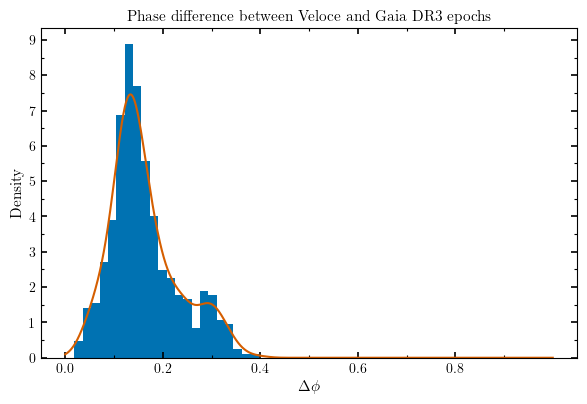

In [13]:
width = 3.46 * 2
height = width / 1.618
fig, axs = plt.subplots(figsize=(width, height))
axs.hist(
    photometric_delta_phase["DELTA_PHASE"],
    bins=int(np.sqrt(len(photometric_delta_phase))),
    density=True,
    color=color_safe["blue"],
    label="Data",
)
# KDE of the phase differences
kde_delta_phase = gaussian_kde(photometric_delta_phase["DELTA_PHASE"])
x_kde = np.linspace(0, 1, 1000)
y_kde = kde_delta_phase(x_kde)
axs.plot(x_kde, y_kde, color=color_safe["dark_orange"], label="KDE")

xlim, ylim = axs.get_xlim(), axs.get_ylim()
x_ticks, x_ticks_minor = np.arange(0, 1, 0.2), np.arange(0, 1, 0.1)
y_ticks, y_ticks_minor = np.arange(0, 10, 1), np.arange(0, 10, 0.5)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_xlim(xlim)
axs.set_ylim(ylim)
axs.set_xlabel(r"$\Delta \phi$", fontsize=label_size)
axs.set_ylabel(r"Density", fontsize=label_size)
axs.set_title(
    "Phase difference between Veloce and Gaia DR3 epochs",
    fontsize=label_size,
)

## Analysis

Set a path to save our results

In [14]:
saving_dir = Path(os.environ.get("RESULTS_DIR", "")).expanduser()
saving_dir.mkdir(exist_ok=True)

We divide the data in train and test set (15% test set)

In [15]:
percentage_test_set = 0.15
targets = veloce_headers["NAME"].to_numpy()

# Divide in training and test sample
idx_train, idx_test = train_test_split(
    np.arange(len(targets)),
    test_size=percentage_test_set,
    random_state=40,
)
veloce_headers["SET"] = "train"
for idx, _ in veloce_headers.iterrows():
    if idx in idx_test:
        veloce_headers.loc[idx, "SET"] = "test"

# Number of training and test samples
n_train = np.sum(veloce_headers["SET"] == "train")
n_test = np.sum(veloce_headers["SET"] == "test")
print(f"Number of training samples: {n_train}")  # noqa: T201
print(f"Number of test samples: {n_test}")  # noqa: T201

Number of training samples: 186
Number of test samples: 33


### Compute sample
Define the phase grid on which to sample the pulsation: 1000 sampled points between $\phi = 0$ and $\phi = 1$

In [16]:
min_phase, max_phase = 0.0, 1.0
n_bins = 1000
phase_grid = np.linspace(min_phase, max_phase, n_bins)
phase_step = phase_grid[1] - phase_grid[0]
print(f"Min and max phase: {min_phase:.3f}, {max_phase:.3f}")  # noqa: T201
print(f"Phase step: {phase_step:.3f}")  # noqa: T201

Min and max phase: 0.000, 1.000
Phase step: 0.001


Compute each VELOCE model at each point of the phase grid to create the sample on which we will perform PCA. 
- `dataset` is a pd.DataFrame that contains both the sample and metadata for each target
- `sample` is a pd.DataFrame just containing the sample (each column correspond to a point of the phase grid defined before)

In [17]:
dataset = pd.DataFrame()
for _, header in veloce_headers.iterrows():
    name = header["NAME"]
    set_type = header["SET"]
    nharm = int(header["N_TERMS_FS"])
    fs_coeffs = veloce_fit[veloce_fit["NAME"] == name]["FS_COEFFS"].iloc[0]
    temp_sample = vf.model.FourierSeries(nharm=nharm).evaluate(fs_coeffs, phase_grid)

    temp = pd.DataFrame(
        {
            "NAME": name,
            "SET": set_type,
            "SAMPLE": [temp_sample],
        },
    )
    dataset = pd.concat([dataset, temp], ignore_index=True)
sample = pd.DataFrame(dataset["SAMPLE"].to_numpy().tolist(), index=dataset.index)

Separate train and test sample

In [18]:
training_set = dataset[dataset["SET"] == "train"]
training_sample = sample[dataset["SET"] == "train"]
test_set = dataset[dataset["SET"] == "test"]
test_sample = sample[dataset["SET"] == "test"]

### Preprocess the samples

I remove the mean to the sample.

In [19]:
mean_training_sample = training_sample.mean()
scaled_training_sample = training_sample - mean_training_sample
scaled_test_sample = test_sample - mean_training_sample

Plot the sample and the scaled sample for the training and test set

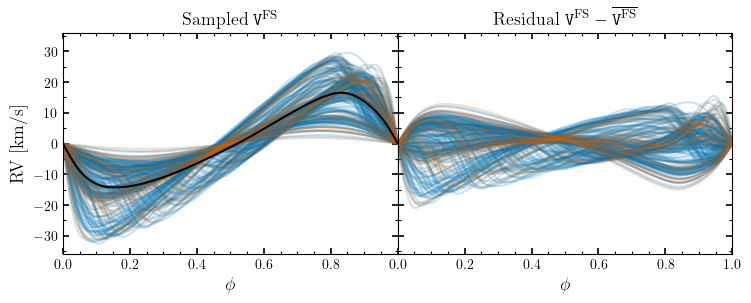

In [20]:
width = 3.46 * 2.2
height = width / 1.618 / 1.5
fig, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)

for _, row in training_sample.iterrows():
    axs[0].plot(phase_grid, row, color=color_safe["blue"], alpha=0.2)
for _, row in test_sample.iterrows():
    axs[0].plot(phase_grid, row, color=color_safe["dark_orange"], alpha=0.2, zorder=2)
for _, row in scaled_training_sample.iterrows():
    axs[1].plot(phase_grid, row, color=color_safe["blue"], alpha=0.2)
for _, row in scaled_test_sample.iterrows():
    axs[1].plot(phase_grid, row, color=color_safe["dark_orange"], alpha=0.2, zorder=2)

axs[0].plot(
    phase_grid,
    mean_training_sample,
    color=color_safe["black"],
    lw=1.5,
    zorder=3,
)
# y lable on the right
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()
axs[0].set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs[0].set_ylabel(r"$\mathrm{RV \ [km/s]}$", fontsize=label_size + 2)
axs[0].set_title(r"Sampled $ \texttt{V}^{\rm FS}$", fontsize=label_size + 2)
axs[1].set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs[1].set_title(
    r"Residual $ \texttt{V}^{\rm FS} - \overline{ \texttt{V}^{\rm FS}}$",
    fontsize=label_size + 2,
)
x_ticks = np.arange(-0.4, 1.6, 0.2)
x_ticks_minor = np.arange(-0.4, 1.6, 0.05)
vf.plot.format_xticks(axs[0], x_ticks[:-3], x_ticks_minor)
vf.plot.format_xticks(axs[1], x_ticks, x_ticks_minor)
axs[0].set_xlim(0, 1)
axs[1].set_xlim(0, 1)
y_ticks = np.arange(-40, 40, 10)
y_ticks_minor = np.arange(-45, 45, 5)
vf.plot.format_yticks(axs[0], y_ticks, y_ticks_minor)
vf.plot.format_yticks(axs[1], y_ticks, y_ticks_minor)
axs[0].set_ylim(-36, 36)
axs[1].set_ylim(-36, 36)
fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.savefig(saving_dir / "scaled_fourier_series.pdf")

### PCA Analysis

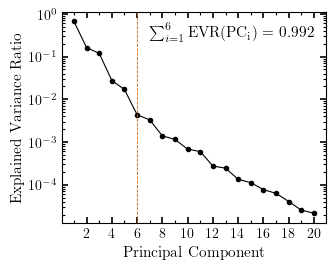

In [21]:
pca = PCA(n_components=20, svd_solver="full")
pca.fit(scaled_training_sample)

# Plot the explained variance ratio
width = 3.46
height = width * 1.618 / 2
fig, axs = plt.subplots(figsize=(width, height))
axs.plot(
    np.arange(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_,
    "o-",
    color=color_safe["black"],
    markersize=3,
    lw=0.8,
)
axs.set_yscale("log")
x_ticks = np.arange(2, 22, 2)
x_ticks_minor = np.arange(1, 21, 1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
yticks, y_ticks_minor = axs.get_yticks(), axs.get_yticks(minor=True)
vf.plot.format_yticks(axs, yticks, y_ticks_minor)
axs.axhline(0, color=color_safe["black"], lw=0.6, ls="--")
axs.axvline(6, color=color_safe["dark_orange"], lw=0.6, ls="--")
axs.text(
    20,
    0.65,
    (
        r"$\sum_{i=1}^6 \mathrm{EVR(PC_{i})=}$"
        f"{sum(pca.explained_variance_ratio_[:6]): .3f}"
    ),
    fontsize=11,
    color=color_safe["black"],
    weight="heavy",
    ha="right",
    va="top",
)
axs.set_xlabel("Principal Component", fontsize=11)
axs.set_ylabel("Explained Variance Ratio", fontsize=11)
fig.tight_layout()
plt.savefig(saving_dir / "pca_explained_variance_ratio_log.pdf", format="pdf")

Number of components retained: 6

In [22]:
pca = PCA(n_components=6, svd_solver="full")
pca.fit(scaled_training_sample)
print(f"PCA explained variance: {sum(pca.explained_variance_ratio_)}")  # noqa: T201

PCA explained variance: 0.9918593608909052


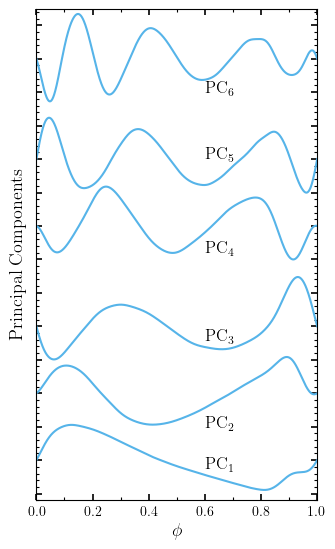

In [23]:
# Plot PCA components
width = 3.46
height = width * 1.618
fig, axs = plt.subplots(figsize=(width, height))
n_components = pca.n_components_
offset_plot_comp = [0.0, 0.1, 0.2, 0.35, 0.45, 0.6]
for i, component in enumerate(pca.components_):
    axs.plot(
        phase_grid,
        component + offset_plot_comp[i],
        label=f"Component {i + 1}",
        color=color_safe["light_blue"],
    )

    y = (component[600] + offset_plot_comp[i]) + 0.01
    if i == 1:
        y -= 0.04
    if i == 3:  # noqa: PLR2004
        y -= 0.04
    if i == 4:  # noqa: PLR2004
        y += 0.03
    if i == 5:  # noqa: PLR2004
        y -= 0.03

    x = 0.6

    axs.text(
        x,
        y,
        r"$\rm{PC_" + str(i + 1) + "}$",
        fontsize=12,
        color=color_safe["black"],
        weight="heavy",
    )

x_ticks = np.arange(-0.4, 1.6, 0.2)
x_ticks_minor = np.arange(-0.4, 1.6, 0.1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
axs.set_xlim(0, 1)
y_ticks = np.arange(-0.1, 0.11 + np.max(offset_plot_comp) + 0.1, 0.05)
y_ticks_minor = np.arange(-0.08, 0.08 + np.max(offset_plot_comp) + 0.1, 0.01)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_ylim(-0.06, 0.074 + np.max(offset_plot_comp))
axs.get_yaxis().set_ticklabels([])
axs.set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs.set_ylabel("Principal Components", fontsize=label_size + 2)
fig.tight_layout()
plt.savefig(saving_dir / "pca_components.pdf", format="pdf")

### Fit VELOCE observations and RV curves (sampled over phase grid) using PCs

First, we define a model of the linear combination of the components

In [24]:
class LinearCombinationPC(vf.model.BaseModel):
    """Linear combination of the PCA components."""

    def __init__(
        self,
        pca: PCA,
        mean_training_sample: np.ndarray,
        phase_grid: np.ndarray = phase_grid,
        name: str = "lcc",
    ) -> None:
        """Initialize the model with the PCA components and the mean training sample."""
        super().__init__(name=name)
        self.pca = pca
        self.phase_grid = phase_grid
        self.components = pca.components_
        self.removed_mean = mean_training_sample

    @property
    def n_params(self) -> int:
        """Number of parameters is equal to the number of PCA components."""
        return self.components.shape[0]

    @property
    def param_names(self) -> list[str]:
        """Parameter names."""
        # pc1, pc2, ..., pcN
        return [f"pc{i}" for i in range(1, self.n_params + 1)]

    def evaluate(
        self,
        theta: list | np.ndarray,
        x: float | list | np.ndarray,
        **kwargs: object,  # noqa: ARG002
    ) -> np.ndarray:
        """Evaluate the model."""
        # Reshape theta to be a 1-dimensional array
        theta = np.array(theta).reshape(-1)
        # Evaluate the linear combination
        interpolated_curve = sp.interpolate.interp1d(
            self.phase_grid,
            self.removed_mean + np.dot(self.components.T, theta),
        )
        return interpolated_curve(x)

Then, we complete the model by adding a constant model to account for $v_\gamma$

In [25]:
pca_puls_model = LinearCombinationPC(
    pca=pca,
    mean_training_sample=mean_training_sample.to_numpy(),
    name="pca_puls",
)

vgamma_model = vf.model.Constant(name="v_gamma")

pca_model = vgamma_model + pca_puls_model

We fit this model to both VELOCE data and the initial sampled model. Any difference in resulting coefficients would then be caused by the phase coverage of the observations, while any discrepancy between the new pca-component-based model and the original model is sympton of the lost information due to the dimensionality reduction.

In [ ]:
fit_rv = []
for _, header in tqdm(veloce_headers.iterrows(), total=len(veloce_headers)):
    name = header["NAME"]
    set_type = header["SET"]

    # Fit the PCs to the VELOCE data

    # 1. Get the observed data for the current target
    # NOTE: we want only the observations that were originally used to fit the
    # VELOCE Fourier series, to allow a more direct comparison between the
    # Fourier series and the PCA model
    target_data = veloce_data[(veloce_data["NAME"] == name) & (veloce_data["MASK"])]
    bjd, rv, rv_err = (
        target_data["BJD"].to_numpy().copy(),
        target_data["RV"].to_numpy().copy(),
        target_data["RV_ERR"].to_numpy().copy(),
    )
    phase = vf.model.calculate_phase(bjd, header["P"], header["E"])

    # 2. If a vgamma trend was accounted for with a polynomial in VELOCE correct for it.
    # So, we remove any trends and fit only the pulsation signal with the PCA model.
    target_veloce_fit = veloce_fit[veloce_fit["NAME"] == name].iloc[0]
    if isinstance(target_veloce_fit["POLY_COEFFS"], np.ndarray):
        trend_model = vf.model.PolynomialBasis(int(header["POLYDEG"]))
        trend = trend_model.evaluate(
            target_veloce_fit["POLY_COEFFS"],
            bjd - header["E"],
        )
        rv -= trend

    # 3. Fit the PCA model to the observed data
    # Only pulsation signal and unique vgamma.
    fit_result = vf.fit.fit_least_squares(
        compiled_model=pca_model,
        x=phase,
        y=rv,
        yerr=rv_err,
        theta_free_init=np.zeros(pca_model.n_params),
    )
    if isinstance(fit_result, vf.fit.FailedFitResult):
        msg = f"Fit failed for {name} in {set_type} set. Reason: {fit_result.message}"
        logger.warning(msg)
        raise vf.fit.FailedFitError(msg)

    # To estimate the uncertainty on the peak-to-peak, we measure the
    # distribution of peak-to-peak values obtained by varying the parameters
    # within their uncertainties.
    rv_fit = pca_model.evaluate(theta=fit_result.theta_free, x=phase_grid)
    p2p_fit = np.ptp(rv_fit)
    n_samples = 200
    p2p_values = np.zeros(n_samples)
    for i in range(n_samples):
        # Sample parameters from the covariance matrix
        sampled_theta = rng.multivariate_normal(
            mean=fit_result.theta_free,
            cov=fit_result.extra["covariance_matrix"],
        )
        rv_sampled = pca_model.evaluate(theta=sampled_theta, x=phase_grid)
        p2p_values[i] = np.ptp(rv_sampled)

    p2p_err = np.std(p2p_values)

    # Furthermore, we can also compute the RMSE of the fit compared with the
    # VELOCE Fourier series fit.

    veloce_fs_coeffs = target_veloce_fit["FS_COEFFS"]
    nharm = int(len(veloce_fs_coeffs) / 2)
    veloce_model = (
        vf.model.FourierSeries(nharm=nharm).evaluate(veloce_fs_coeffs, phase_grid)
        + target_veloce_fit["VGAMMA"]
    )
    rmse_fit_veloce = np.sqrt(np.mean((rv_fit - veloce_model) ** 2))

    # Save the results
    fit_rv.append(
        {
            "NAME": name,
            "SET": set_type,
            "LS_RESULT": fit_result,
            "CHI2": fit_result.stats.chi2,
            "NORM_CHI2": fit_result.stats.reduced_chi2,
            "RMSE": fit_result.stats.rmse,
            "VGAMMA": fit_result.theta_free[0],
            "VGAMMA_ERR": fit_result.extra["theta_err"][0],
            "P2P": p2p_fit,
            "P2P_ERR": p2p_err,
            "RMSE_VELOCE": rmse_fit_veloce,
        },
    )


fit_rv_df = pd.DataFrame(fit_rv)

  0%|          | 0/219 [00:00<?, ?it/s]

#### Compare fit over VELOCE data with VELOCE's fit results

In [27]:
# Target by target comparison of the PCA fit with the VELOCE Fourier series fit,
# in terms of peak-to-peak and vgamma. Few keys are added to facilitate the
# analysis later on.
for idx, row in fit_rv_df.iterrows():
    name = row["NAME"]
    veloce_headers_row = veloce_headers[veloce_headers["NAME"] == name].iloc[0]
    veloce_fit_row = veloce_fit[veloce_fit["NAME"] == name].iloc[0]

    # Peak-to-peak comparison
    fit_rv_df.loc[idx, "P2P_DELTA"] = row["P2P"] - veloce_headers_row["PEAK2PEAK"]
    fit_rv_df.loc[idx, "P2P_DELTA_ERR"] = row["P2P_ERR"]  # We assume VELOCE to be exact
    fit_rv_df.loc[idx, "P2P_DELTA_RATIO"] = (
        row["P2P"] - veloce_headers_row["PEAK2PEAK"]
    ) / veloce_headers_row["PEAK2PEAK"]
    fit_rv_df.loc[idx, "P2P_DELTA_RATIO_ERR"] = (
        row["P2P_ERR"] / veloce_headers_row["PEAK2PEAK"]
    )

    # Vgamma comparison
    fit_rv_df.loc[idx, "VGAMMA_DELTA"] = row["VGAMMA"] - veloce_fit_row["VGAMMA"]
    fit_rv_df.loc[idx, "VGAMMA_DELTA_ERR"] = row["VGAMMA_ERR"]  # Same as above
    fit_rv_df.loc[idx, "VGAMMA_DELTA_RATIO"] = (
        row["VGAMMA"] - veloce_fit_row["VGAMMA"]
    ) / veloce_headers_row["PEAK2PEAK"]
    fit_rv_df.loc[idx, "VGAMMA_DELTA_RATIO_ERR"] = (
        row["VGAMMA_ERR"] / veloce_headers_row["PEAK2PEAK"]
    )

    # Add period to the dataframe for later analysis
    fit_rv_df.loc[idx, "P"] = veloce_headers_row["P"]

    # Add scaled RMSE
    fit_rv_df.loc[idx, "RMSE_SCALED"] = row["RMSE"] / veloce_headers_row["PEAK2PEAK"]
    fit_rv_df.loc[idx, "RMSE_VELOCE_SCALED"] = (
        row["RMSE_VELOCE"] / veloce_headers_row["PEAK2PEAK"]
    )

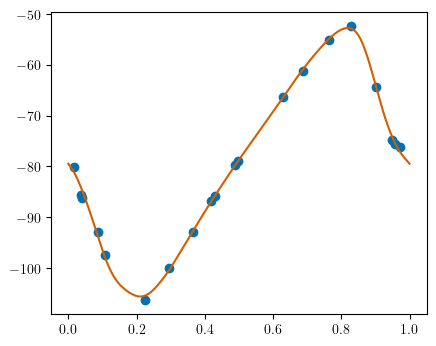

In [28]:
# Plot fit for one of the targets
target_name = "CY Cas"
target_fit = fit_rv_df[fit_rv_df["NAME"] == target_name]["LS_RESULT"].iloc[0]
width = 3.46 * 1.4
height = width * 1.618 / 2
fig, ax = plt.subplots(figsize=(width, height))
ax.plot(target_fit.x, target_fit.y, "o", label="Data", color=color_safe["blue"])
ax.plot(
    phase_grid,
    pca_model.evaluate(theta=target_fit.theta_free, x=phase_grid),
    label="PCA Fit",
    color=color_safe["dark_orange"],
)

##### Handle Outliers

Determine and remove outliers based on z-score (as before) on the $v_\gamma$ and $P2P$ difference distrubutions

In [29]:
fit_rv_df["OUTLIER"] = False
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"].astype(bool)

# Absolute Z-score for vgamma below 3
zscore_vgamma_rv = sp.stats.zscore(fit_rv_df["VGAMMA_DELTA"])
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"] | (np.abs(zscore_vgamma_rv) > z_score_limit)
# Only outlier: AV Sgr
# it is caused by the fact that we don't have many observations and the phase
# sampling is not good enough. No points between phase 0.85-0.25.

# Absolute Z-score for the delta p2p below 3
zscore_p2p_rv = sp.stats.zscore(fit_rv_df["P2P_DELTA"])
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"] | (np.abs(zscore_p2p_rv) > z_score_limit)
# No outliers found from the delta p2p

# Show outliers
fit_rv_df[fit_rv_df["OUTLIER"]]

,NAME,SET,LS_RESULT,CHI2,NORM_CHI2,RMSE,VGAMMA,VGAMMA_ERR,P2P,P2P_ERR,...,P2P_DELTA_RATIO,P2P_DELTA_RATIO_ERR,VGAMMA_DELTA,VGAMMA_DELTA_ERR,VGAMMA_DELTA_RATIO,VGAMMA_DELTA_RATIO_ERR,P,RMSE_SCALED,RMSE_VELOCE_SCALED,OUTLIER
35,AV Sgr,test,"SuccessfulFitResult(method='least_squares', op...",1.387778,0.693889,0.029683,19.448818,1.381076,66.741806,9.602261,...,0.412473,0.203215,-4.115029,1.381076,-0.087087,0.029228,15.329361,0.000628,0.198826,True


In [30]:
# Get only the non-outliers
fit_rv_no_outliers = fit_rv_df[~fit_rv_df["OUTLIER"]]

fit_rv_train_df = fit_rv_no_outliers[fit_rv_no_outliers["SET"] == "train"]
fit_rv_test_df = fit_rv_no_outliers[fit_rv_no_outliers["SET"] == "test"]

##### Plot the results of fitting VELOCE observations

In [31]:
highlight_particular_cases = {
    "BB Gem": 1,
    "IR Cep": 2,
    "alf UMi": 3,
    "V0440 Per": 4,
    "ASAS J064540+0330.4": 5,
}

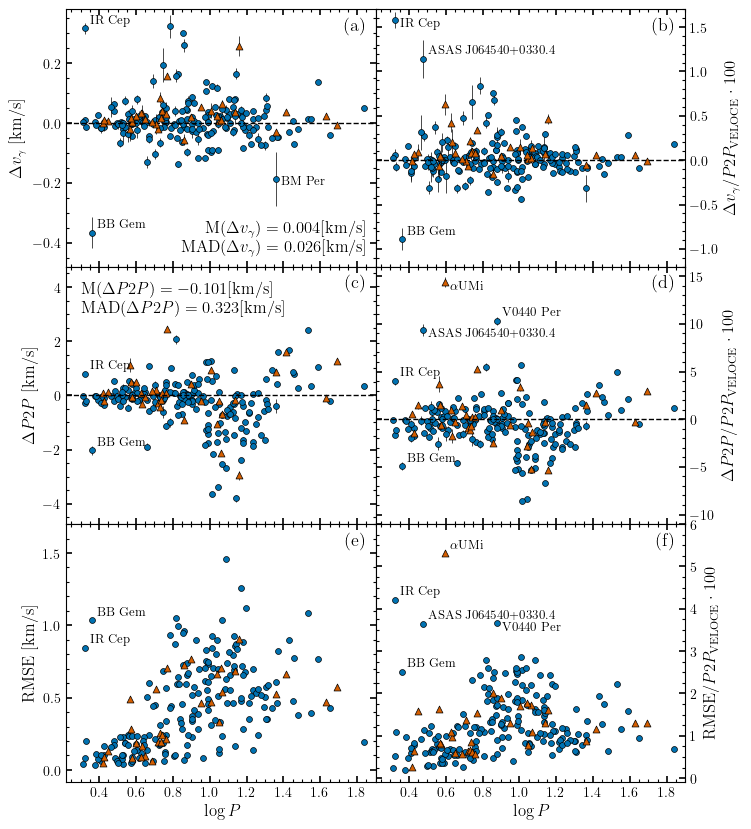

In [32]:
width = 3.46 * 2.2
height = width * 1.618 / 2 * 3 / 2.2  # / 2
fig, axs_grid = plt.subplots(
    3,
    2,
    figsize=(width, height),
    sharex=True,
    gridspec_kw={"hspace": 0, "wspace": 0},
)
x_ticks = np.arange(0.2, 2, 0.2)
x_ticks_minor = np.arange(0.2, 2, 0.05)
xlims = [0.22, 1.9]
for i, axs in enumerate(axs_grid.flat):
    panels = ["a", "b", "c", "d", "e", "f"]
    axs.text(
        0.97,
        0.97,
        f"({panels[i]})",
        transform=axs.transAxes,
        fontsize=label_size + 2,
        ha="right",
        va="top",
    )
    if i % 2 == 1:
        axs.yaxis.set_label_position("right")
        axs.yaxis.tick_right()
    if i == 0:
        train_delta_vgamma = fit_rv_train_df["VGAMMA_DELTA"]
        train_delta_vgamma_err = fit_rv_train_df["VGAMMA_DELTA_ERR"]
        test_delta_vgamma = fit_rv_test_df["VGAMMA_DELTA"]
        test_delta_vgamma_err = fit_rv_test_df["VGAMMA_DELTA_ERR"]

        # Training set
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma,
            yerr=train_delta_vgamma_err,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        sc = axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Test set
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma,
            yerr=test_delta_vgamma_err,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=3,
        )
        sc = axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=4,
        )

        # Only annotate targets in the outliers list
        for _, row in fit_rv_df.iterrows():
            if row["NAME"] in ["IR Cep", "BB Gem"]:
                axs.annotate(
                    row["NAME"],
                    (np.log10(row["P"]), row["VGAMMA_DELTA"]),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, 0.4),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )
            if row["NAME"] == "BM Per":
                axs.annotate(
                    row["NAME"],
                    (np.log10(row["P"]), row["VGAMMA_DELTA"]),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, -0.4),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )

        y_ticks = np.arange(-0.6, 0.6, 0.2)
        y_ticks_minor = np.arange(-0.8, 0.6, 0.05)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.48, 0.38)
        text = (
            r"$\mathrm{M}(\Delta v_\gamma) = "
            f"{np.median(fit_rv_df['VGAMMA_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]\n"
        text += (
            r"$\mathrm{MAD}(\Delta v_\gamma) = "
            f"{sp.stats.median_abs_deviation(fit_rv_df['VGAMMA_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]"
        axs.text(
            1.85,
            -0.45,
            s=text,
            fontsize=12,
            verticalalignment="bottom",
            horizontalalignment="right",
        )
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")

        axs.set_ylabel(r"$\Delta v_\gamma \ \mathrm{[km/s]}$", fontsize=12)

    elif i == 1:
        train_delta_vgamma_ratio = fit_rv_train_df["VGAMMA_DELTA_RATIO"]
        train_delta_vgamma_ratio_err = fit_rv_train_df["VGAMMA_DELTA_RATIO_ERR"]
        test_delta_vgamma_ratio = fit_rv_test_df["VGAMMA_DELTA_RATIO"]
        test_delta_vgamma_ratio_err = fit_rv_test_df["VGAMMA_DELTA_RATIO_ERR"]
        # Training set
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma_ratio * 100,
            yerr=train_delta_vgamma_ratio_err * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        sc = axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma_ratio * 100,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Test set
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma_ratio * 100,
            yerr=test_delta_vgamma_ratio_err * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=3,
        )
        sc = axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma_ratio * 100,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=4,
        )
        # Annotate targets
        for _, row in fit_rv_df.iterrows():
            if row["NAME"] in highlight_particular_cases and row["NAME"] not in [
                "alf UMi",
                "V0440 Per",
            ]:
                yyy = 0.4 if row["NAME"] not in ["IR Cep"] else -0.6
                axs.annotate(
                    row["NAME"],
                    (np.log10(row["P"]), row["VGAMMA_DELTA_RATIO"] * 100),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, yyy),
                    ha="left",
                    fontsize=9,
                    color="black",
                    zorder=10,
                )

        y_ticks = np.arange(-1.0, 2, 0.5)
        y_ticks_minor = np.arange(-1.3, 3, 0.1)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-1.2, 1.7)
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")
        axs.set_ylabel(
            r"$\Delta v_\gamma / P2P_{\mathrm{VELOCE}} \cdot 100$",
            fontsize=12,
        )

    elif i == 2:  # noqa: PLR2004
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA"],
            yerr=fit_rv_train_df["P2P_DELTA_ERR"],
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA"],
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA"],
            yerr=fit_rv_test_df["P2P_DELTA_ERR"],
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA"],
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        # Only annotate targets in the outliers list
        for _, row in fit_rv_df.iterrows():
            if row["NAME"] in ["IR Cep", "BB Gem"]:
                axs.annotate(
                    row["NAME"],
                    (np.log10(row["P"]), row["P2P_DELTA"]),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, 0.4),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )

        y_ticks = np.arange(-8, 6, 2)
        y_ticks_minor = np.arange(-8, 6, 0.5)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-4.75, 4.75)

        text = (
            r"$\mathrm{M}(\Delta  P2P) = "
            f"{np.median(fit_rv_no_outliers['P2P_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]\n"
        text += (
            r"$\mathrm{MAD}(\Delta  P2P) = "
            f"{sp.stats.median_abs_deviation(fit_rv_no_outliers['P2P_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]"
        axs.text(
            0.3,
            4.25,
            s=text,
            fontsize=12,
            verticalalignment="top",
            horizontalalignment="left",
        )
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")
        axs.set_ylabel(r"$\Delta  P2P \ \mathrm{[km/s]}$", fontsize=12)

    elif i == 3:  # noqa: PLR2004
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA_RATIO"] * 100,
            yerr=fit_rv_train_df["P2P_DELTA_RATIO_ERR"] * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA_RATIO"] * 100,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA_RATIO"] * 100,
            yerr=fit_rv_test_df["P2P_DELTA_RATIO_ERR"] * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA_RATIO"] * 100,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        # Only annotate targets with particular results.
        for _, row in fit_rv_no_outliers.iterrows():
            if row["NAME"] in highlight_particular_cases:
                yyy = (
                    0.4
                    if row["NAME"] not in ["ASAS J064540+0330.4", "alf UMi"]
                    else -0.6
                )
                text_note = row["NAME"] if row["NAME"] != "alf UMi" else r"$\alpha$UMi"
                axs.annotate(
                    text_note,
                    (np.log10(row["P"]), row["P2P_DELTA_RATIO"] * 100),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, yyy),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )

        y_ticks = 100 * np.arange(-0.15, 0.2, 0.05)
        y_ticks_minor = 100 * np.arange(-0.2, 0.2, 0.01)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.11 * 100, 0.16 * 100)
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")

        axs.set_ylabel(
            r"$\Delta  P2P / P2P_{\mathrm{VELOCE}} \cdot 100$",
            fontsize=12,
        )

    elif i == 4:  # noqa: PLR2004
        axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["RMSE_VELOCE"],
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["RMSE_VELOCE"],
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Annotate targets
        for _, row in fit_rv_df.iterrows():
            if row["NAME"] in ["IR Cep", "BB Gem"]:
                axs.annotate(
                    row["NAME"],
                    (np.log10(row["P"]), row["RMSE_VELOCE"]),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, 0.4),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )

        y_ticks = np.arange(0, 3, 0.5)
        y_ticks_minor = np.arange(0, 3, 0.1)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.08, 1.7)

        axs.set_ylabel(r"$\mathrm{RMSE}\ \mathrm{[km/s]}$", fontsize=12)

    elif i == 5:  # noqa: PLR2004
        veloce_headers_target = veloce_headers[veloce_headers["NAME"] == name].iloc[0]
        axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["RMSE_VELOCE_SCALED"] * 100,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["RMSE_VELOCE_SCALED"] * 100,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        # Annotate targets
        for _, row in fit_rv_df.iterrows():
            if row["NAME"] in highlight_particular_cases:
                yyy = 0.4 if row["NAME"] != "V0440 Per" else -0.6
                text_note = row["NAME"] if row["NAME"] != "alf UMi" else r"$\alpha$UMi"
                axs.annotate(
                    text_note,
                    (np.log10(row["P"]), row["RMSE_VELOCE_SCALED"] * 100),
                    xycoords="data",
                    textcoords="offset fontsize",
                    xytext=(0.4, yyy),
                    ha="left",
                    fontsize=9,
                    color="black",  # Optional: highlight outliers
                    zorder=10,
                )

        y_ticks = np.arange(0, 7, 1)
        y_ticks_minor = np.arange(0, 7, 0.25)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.08, 6)

        axs.set_ylabel(
            r"$\mathrm{RMSE}  / P2P_{\mathrm{VELOCE}} \cdot 100 $",
            fontsize=12,
        )
    else:
        continue
    vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
    axs.set_xlim(*xlims)
axs_grid[-1, -1].set_xlabel(r"$\log P$", fontsize=12)
axs_grid[2, 0].set_xlabel(r"$\log P$", fontsize=12)
fig.tight_layout()
plt.savefig(saving_dir / "results_fit_rv_stats.pdf", format="pdf")

#### Fit VELOCE's RV curves using the Principal Components

In [37]:
dataset

,NAME,SET,SAMPLE
0,AA Gem,train,"[-4.6000072306817685e-08, -0.08650405637946144..."
1,AB Cam,train,"[-8.656029226727924e-10, -0.4490512648447223, ..."
2,AC Mon,train,"[-3.5409287724164074e-08, -0.28877907758272237..."
3,AD Pup,train,"[3.548515647988637e-11, -0.08977585433051663, ..."
4,AH Vel,train,"[-1.768574175997628e-11, -0.07954839416284487,..."
...,...,...,...
214,bet Dor,train,"[-2.2274420363732617e-09, -0.1375494443467271,..."
215,del Cep,train,"[-5.136809636679951e-08, -0.3666403879386091, ..."
216,eta Aql,train,"[1.7617080017018338e-10, -0.3158531540604166, ..."
217,l Car,train,"[1.4191618366576897e-10, -0.36306846683086463,..."


In [ ]:
fit_curve = []
for _, row in tqdm(veloce_headers.iterrows(), total=len(veloce_headers)):
    name = row["NAME"]
    set_type = row["SET"]

    # Reconstruct the VELOCE fit curve for the current target.
    target_dataset = dataset[dataset["NAME"] == name].iloc[0]
    veloce_pulsation = target_dataset["SAMPLE"]
    veloce_vgamma = veloce_fit[veloce_fit["NAME"] == name]["VGAMMA"].iloc[0]
    veloce_rv_curve = veloce_pulsation + veloce_vgamma

    fit_result = vf.fit.fit_least_squares(
        compiled_model=pca_model,
        x=phase_grid,
        y=veloce_rv_curve,
        yerr=None,  # We don't have uncertainties on the VELOCE curve => None
        theta_free_init=np.zeros(pca_model.n_params),
    )

    if isinstance(fit_result, vf.fit.FailedFitResult):
        msg = f"Fit failed for {name} in {set_type} set. Reason: {fit_result.message}"
        logger.warning(msg)
        raise vf.fit.FailedFitError(msg)

    # To estimate the uncertainty on the peak-to-peak, we measure the
    # distribution of peak-to-peak values obtained by varying the parameters
    # within their uncertainties.
    rv_fit = pca_model.evaluate(theta=fit_result.theta_free, x=phase_grid)
    p2p_fit = np.ptp(rv_fit)
    n_samples = 200
    p2p_values = np.zeros(n_samples)
    for i in range(n_samples):
        # Sample parameters from the covariance matrix
        sampled_theta = rng.multivariate_normal(
            mean=fit_result.theta_free,
            cov=fit_result.extra["covariance_matrix"],
        )
        rv_sampled = pca_model.evaluate(theta=sampled_theta, x=phase_grid)
        p2p_values[i] = np.ptp(rv_sampled)

    p2p_err = np.std(p2p_values)

    # Save the results
    fit_curve.append(
        {
            "NAME": name,
            "SET": set_type,
            "LS_RESULT": fit_result,
            "CHI2": fit_result.stats.chi2,
            "NORM_CHI2": fit_result.stats.reduced_chi2,
            "RMSE": fit_result.stats.rmse,
            "VGAMMA": fit_result.theta_free[0],
            "VGAMMA_ERR": fit_result.extra["theta_err"][0],
            "VGAMMA_ERR_SCALED": fit_result.extra["theta_err_scaled"][0],
            "P2P": p2p_fit,
            "P2P_ERR": p2p_err,
        },
    )

fit_curve_df = pd.DataFrame(fit_curve)

  0%|          | 0/219 [00:00<?, ?it/s]

In [ ]:
fit_rv = []
for _, header in tqdm(veloce_headers.iterrows(), total=len(veloce_headers)):
    name = header["NAME"]
    set_type = header["SET"]

    # Fit the PCs to the VELOCE data

    # 1. Get the observed data for the current target
    # NOTE: we want only the observations that were originally used to fit the
    # VELOCE Fourier series, to allow a more direct comparison between the
    # Fourier series and the PCA model
    target_data = veloce_data[(veloce_data["NAME"] == name) & (veloce_data["MASK"])]
    bjd, rv, rv_err = (
        target_data["BJD"].to_numpy().copy(),
        target_data["RV"].to_numpy().copy(),
        target_data["RV_ERR"].to_numpy().copy(),
    )
    phase = vf.model.calculate_phase(bjd, header["P"], header["E"])

    # 2. If a vgamma trend was accounted for with a polynomial in VELOCE correct for it.
    # So, we remove any trends and fit only the pulsation signal with the PCA model.
    target_veloce_fit = veloce_fit[veloce_fit["NAME"] == name].iloc[0]
    if isinstance(target_veloce_fit["POLY_COEFFS"], np.ndarray):
        trend_model = vf.model.PolynomialBasis(int(header["POLYDEG"]))
        trend = trend_model.evaluate(
            target_veloce_fit["POLY_COEFFS"],
            bjd - header["E"],
        )
        rv -= trend

    # 3. Fit the PCA model to the observed data
    # Only pulsation signal and unique vgamma.
    fit_result = vf.fit.fit_least_squares(
        compiled_model=pca_model,
        x=phase,
        y=rv,
        yerr=rv_err,
        theta_free_init=np.zeros(pca_model.n_params),
    )
    if isinstance(fit_result, vf.fit.FailedFitResult):
        msg = f"Fit failed for {name} in {set_type} set. Reason: {fit_result.message}"
        logger.warning(msg)
        raise vf.fit.FailedFitError(msg)

    # To estimate the uncertainty on the peak-to-peak, we measure the
    # distribution of peak-to-peak values obtained by varying the parameters
    # within their uncertainties.
    phase_fit = np.linspace(0, 1, 1000)
    rv_fit = pca_model.evaluate(theta=fit_result.theta_free, x=phase_fit)
    p2p_fit = np.ptp(rv_fit)
    n_samples = 200
    p2p_values = np.zeros(n_samples)
    for i in range(n_samples):
        # Sample parameters from the covariance matrix
        sampled_theta = rng.multivariate_normal(
            mean=fit_result.theta_free,
            cov=fit_result.extra["covariance_matrix"],
        )
        rv_sampled = pca_model.evaluate(theta=sampled_theta, x=phase_fit)
        p2p_values[i] = np.ptp(rv_sampled)

    p2p_err = np.std(p2p_values)

    # Furthermore, we can also compute the RMSE of the fit compared with the
    # VELOCE Fourier series fit.

    veloce_fs_coeffs = target_veloce_fit["FS_COEFFS"]
    nharm = int(len(veloce_fs_coeffs) / 2)
    veloce_model = (
        vf.model.FourierSeries(nharm=nharm).evaluate(veloce_fs_coeffs, phase_grid)
        + target_veloce_fit["VGAMMA"]
    )
    rmse_fit_veloce = np.sqrt(np.mean((rv_fit - veloce_model) ** 2))

    # Save the results
    fit_rv.append(
        {
            "NAME": name,
            "SET": set_type,
            "LS_RESULT": fit_result,
            "CHI2": fit_result.stats.chi2,
            "NORM_CHI2": fit_result.stats.reduced_chi2,
            "RMSE": fit_result.stats.rmse,
            "VGAMMA": fit_result.theta_free[0],
            "VGAMMA_ERR": fit_result.extra["theta_err"][0],
            "P2P": p2p_fit,
            "P2P_ERR": p2p_err,
            "RMSE_VELOCE": rmse_fit_veloce,
        },
    )


fit_rv_df = pd.DataFrame(fit_rv)

# REST OF THE ANALYSIS TO BE DONE